EDA

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import shapiro, pearsonr, spearmanr

In [8]:
df1 = pd.read_csv("../data/emancipacion.csv", sep="\t", encoding="cp1252")
df2 = pd.read_csv("../data/salario.csv", sep="\t", encoding="cp1252")
df1_nogenero = pd.read_csv("../data/emancipacionsingenero.csv", sep="\t", encoding="cp1252")
df2_nogenero = pd.read_csv("../data/salariosingenero.csv", sep="\t", encoding="cp1252")
df3 = pd.read_csv("../data/rent_spain_scraping_dataset.csv")

In [9]:
# Periodo 2020-2018
df1.head()

,Total Nacional,Comunidades y Ciudades Autónomas,Situación en el hogar,Grupo de edad,Sexo,periodo,Total
0,Total Nacional,Andalucía,Personas que conviven con su cónyuge,25-34 años,Hombre,2020,"69,9"
1,Total Nacional,Andalucía,Personas que conviven con su cónyuge,25-34 años,Hombre,2019,"83,9"
2,Total Nacional,Andalucía,Personas que conviven con su cónyuge,25-34 años,Hombre,2018,"78,8"
3,Total Nacional,Andalucía,Personas que conviven con su cónyuge,25-34 años,Mujer,2020,"114,0"
4,Total Nacional,Andalucía,Personas que conviven con su cónyuge,25-34 años,Mujer,2019,"141,2"


In [10]:
# Periodo 2020-2018
df2.head()

,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
0,Andalucía,De 25 a 34 años,Mujeres,2020,"14.969,70"
1,Andalucía,De 25 a 34 años,Mujeres,2019,"15.058,34"
2,Andalucía,De 25 a 34 años,Mujeres,2018,"14.473,92"
3,Andalucía,De 25 a 34 años,Hombres,2020,"18.357,06"
4,Andalucía,De 25 a 34 años,Hombres,2019,"17.978,73"


In [11]:
df3.head()

,Unnamed: 0,provincia,comunidad autonoma,titulo,precio,habitaciones,metros,total inmuebles/comunidad
0,0,La Coruña,Galicia,NaN,NaN,NaN,NaN,1751
1,1,La Coruña,Galicia,"Chalet pareado en A Zapateira, Culleredo",1100.0,4.0,243,1751
2,2,La Coruña,Galicia,"Chalet pareado en Elviña - A Zapateira, A Coruña",1100.0,4.0,243,1751
3,3,La Coruña,Galicia,"Ático en avenida Pasaxe, 35, Los Castros - Cas...",450.0,NaN,Planta 4ª exterior con ascen,1751
4,4,La Coruña,Galicia,"Piso en calle de Fernando III o Santo, 9, Ensa...",1000.0,4.0,100,1751


In [12]:
# Borramos grupo de edad que es siempre el mismo
df1.drop(columns=["Grupo de edad"], inplace=True)

# Pasamos a miles de personas para poder ver el df mejor
df1["Total"] = (
    pd.to_numeric(df1["Total"].astype(str).str.replace(",", ".", regex=False), errors="coerce") * 1000
).round().astype("Int64")

# Juntamos a los no emancipados y los diferenciamos de los si emancipados
no_emancipados = [
    "Hijos/Hijas no del padre o madre solos",
    "Hijos/Hijas del padre o madre solos"
]

df1["Emancipado"] = df1["Situación en el hogar"].isin(no_emancipados)
df1["Emancipado"] = df1["Emancipado"].replace({
    True: "No emancipado",
    False: "Si emancipado"
})

df1 = df1.groupby(
    ["Comunidades y Ciudades Autónomas", "Sexo", "periodo", "Emancipado"],
    as_index=False
)["Total"].sum()

df1 = df1.pivot(
    index=["Comunidades y Ciudades Autónomas", "Sexo", "periodo"],
    columns="Emancipado",
    values="Total"
).reset_index()

df1.columns.name = None

# Hacemos las proporciones de los si emancipados y no emancipados
df1["total_personas"] = df1["Si emancipado"] + df1["No emancipado"]

df1["Si emancipado%"] = df1["Si emancipado"] / df1["total_personas"]
df1["No emancipado%"] = df1["No emancipado"] / df1["total_personas"]


df1["Si emancipado%"] = df1["Si emancipado%"] * 100
df1["No emancipado%"] = df1["No emancipado%"] * 100

df1["Si emancipado%"] = df1["Si emancipado%"].round(3)
df1["No emancipado%"] = df1["No emancipado%"].round(3)

df1.drop(columns=["total_personas"], inplace=True)


In [13]:
df1.head()

,Comunidades y Ciudades Autónomas,Sexo,periodo,No emancipado,Si emancipado,Si emancipado%,No emancipado%
0,Andalucía,Hombre,2018,255100,254100,49.902,50.098
1,Andalucía,Hombre,2019,255000,248400,49.344,50.656
2,Andalucía,Hombre,2020,249600,248000,49.839,50.161
3,Andalucía,Mujer,2018,174700,326700,65.158,34.842
4,Andalucía,Mujer,2019,164500,329100,66.673,33.327


In [14]:
# Borramos grupo de edad
df2.drop(columns=["Edad del trabajador"], inplace=True)

# Pasamos los valores a numeros
df2["Total"] = pd.to_numeric(
    df2["Total"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
    errors="coerce"
).abs()

# Ponemos sexo en singular
df2["Sexo"] = df2["Sexo"].replace({
    "Hombres": "Hombre",
    "Mujeres": "Mujer"
})

In [15]:
df2.head()

,Comunidades y Ciudades Autónomas,Sexo,Periodo,Total
0,Andalucía,Mujer,2020,14969.70
1,Andalucía,Mujer,2019,15058.34
2,Andalucía,Mujer,2018,14473.92
3,Andalucía,Hombre,2020,18357.06
4,Andalucía,Hombre,2019,17978.73


In [16]:
# Borramos grupo de edad que es siempre el mismo
df1_nogenero.drop(columns=["Grupo de edad", "Sexo"], inplace=True)

# Pasamos a miles de personas para poder ver el df mejor
df1_nogenero["Total"] = (
    pd.to_numeric(df1_nogenero["Total"].astype(str).str.replace(",", ".", regex=False), errors="coerce") * 1000
).round().astype("Int64")

# Juntamos a los no emancipados y los diferenciamos de los si emancipados
no_emancipados = [
    "Hijos/Hijas no del padre o madre solos",
    "Hijos/Hijas del padre o madre solos"
]

df1_nogenero["Emancipado"] = df1_nogenero["Situación en el hogar"].isin(no_emancipados)
df1_nogenero["Emancipado"] = df1_nogenero["Emancipado"].replace({
    True: "No emancipado",
    False: "Si emancipado"
})

df1_nogenero = df1_nogenero.groupby(
    ["Comunidades y Ciudades Autónomas", "periodo", "Emancipado"],
    as_index=False
)["Total"].sum()

df1_nogenero = df1_nogenero.pivot(
    index=["Comunidades y Ciudades Autónomas", "periodo"],
    columns="Emancipado",
    values="Total"
).reset_index()

df1_nogenero.columns.name = None

# Hacemos las proporciones de los si emancipados y no emancipados
df1_nogenero["total_personas"] = df1_nogenero["Si emancipado"] + df1_nogenero["No emancipado"]
df1_nogenero["Si emancipado%"] = df1_nogenero["Si emancipado"] / df1_nogenero["total_personas"]
df1_nogenero["No emancipado%"] = df1_nogenero["No emancipado"] / df1_nogenero["total_personas"]


df1_nogenero["Si emancipado%"] = df1_nogenero["Si emancipado%"] * 100
df1_nogenero["No emancipado%"] = df1_nogenero["No emancipado%"] * 100

df1_nogenero["Si emancipado%"] = df1_nogenero["Si emancipado%"].round(3)
df1_nogenero["No emancipado%"] = df1_nogenero["No emancipado%"].round(3)

df1_nogenero.drop(columns=["total_personas"], inplace=True)


In [17]:
df1_nogenero.head()

,Comunidades y Ciudades Autónomas,periodo,No emancipado,Si emancipado,Si emancipado%,No emancipado%
0,Andalucía,2018,429900,580900,57.469,42.531
1,Andalucía,2019,419400,577600,57.934,42.066
2,Andalucía,2020,430500,553400,56.246,43.754
3,Aragón,2018,54100,84000,60.825,39.175
4,Aragón,2019,53300,84500,61.321,38.679


In [18]:
# Borramos grupo de edad
df2_nogenero.drop(columns=["Edad del trabajador"], inplace=True)

# Pasamos los valores a numeros
df2_nogenero["Total"] = pd.to_numeric(
    df2_nogenero["Total"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
    errors="coerce"
).abs()

In [19]:
df2_nogenero.head()

,Comunidades y Ciudades Autónomas,Sexo,Periodo,Total
0,Andalucía,Ambos sexos,2020,16643.35
1,Andalucía,Ambos sexos,2019,16509.01
2,Andalucía,Ambos sexos,2018,16293.48
3,Aragón,Ambos sexos,2020,18919.42
4,Aragón,Ambos sexos,2019,19006.76


In [20]:
df3 = df3[~df3["comunidad autonoma"].isin(["Ceuta", "Melilla"])]

df_pisos = df3.copy()

#Borramos las columnas que no nos sirven y que además contienen muchos valores nulos
df_pisos.drop(columns=["Unnamed: 0","provincia", "titulo", "habitaciones", "metros"], inplace=True)

# hemos eliminado una casa de galicia porque no teniamos el precio, vamos a tener que restar uno en el total de inmuebles/comunidad
df_pisos = df_pisos.dropna()

# Agrupamos los pisos por comunidad autónoma y obtenemos la mediana de los precios, despues redondeamos.
df_pisos_ccaa = df_pisos.groupby("comunidad autonoma", as_index=False).agg(
    precio_mediano=("precio", "median"),
    total_inmuebles=("total inmuebles/comunidad", "first")
)

df_pisos_ccaa["precio_mediano"] = df_pisos_ccaa["precio_mediano"].round().astype("Int64")

# Restamos la fila de antes al total
df_pisos_ccaa.loc[df_pisos_ccaa["comunidad autonoma"] == "Galicia", "total_inmuebles"] -= 1


In [21]:
df_pisos_ccaa.head()

,comunidad autonoma,precio_mediano,total_inmuebles
0,Andalucia,750,1345
1,Aragon,650,260
2,Asturias,620,2470
3,Baleares,1750,2317
4,Canarias,828,1743


Análisis Univariante

df_plot = df1.copy()
df_plot["periodo"] = pd.to_numeric(df_plot["periodo"], errors="coerce")
df_plot = df_plot[df_plot["Sexo"].isin(["Hombre", "Mujer"])].copy()

for ccaa in sorted(df_plot["Comunidades y Ciudades Autónomas"].dropna().unique()):
    datos = df_plot[df_plot["Comunidades y Ciudades Autónomas"] == ccaa].copy()
    datos = datos.sort_values(["Sexo", "periodo"])

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=datos,
        x="periodo",
        y="No emancipado%",
        hue="Sexo",
        marker="o"
    )

    for _, row in datos.iterrows():
        plt.text(
            row["periodo"],
            row["No emancipado%"],
            f'{row["No emancipado%"]:.1f}',
            fontsize=9,
            ha="center",
            va="bottom"
        )

    plt.title(f"No emancipados (%) en {ccaa}")
    plt.xlabel("Periodo")
    plt.ylabel("No emancipado (%)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

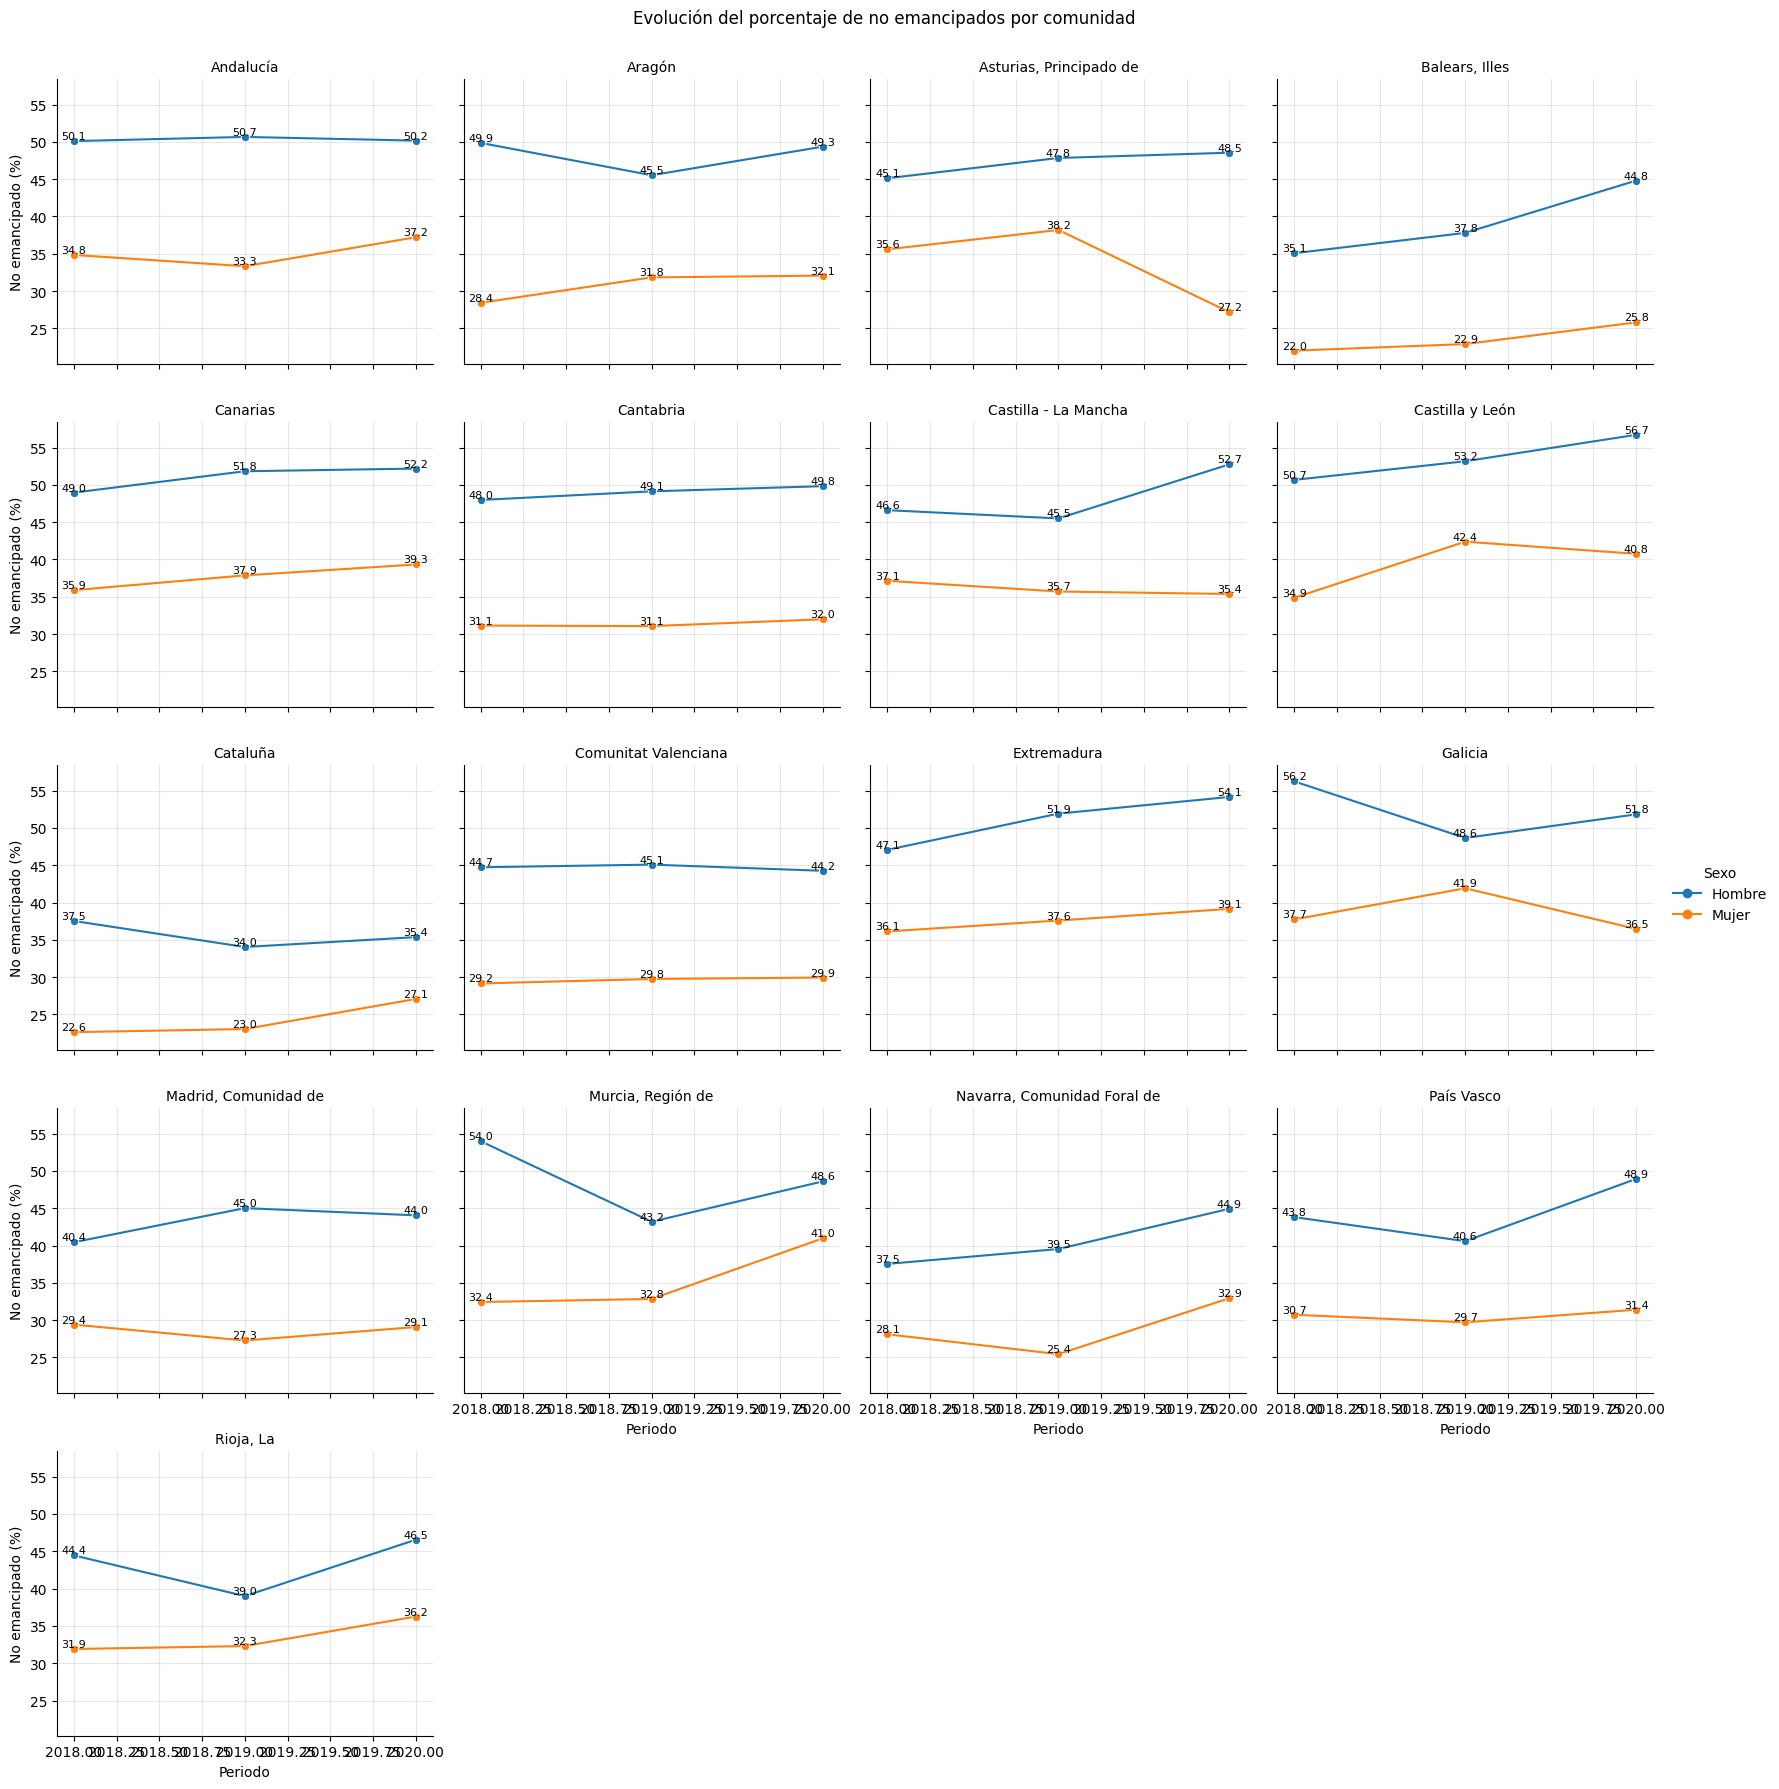

In [22]:
df_plot = df1.copy()

df_plot["periodo"] = pd.to_numeric(df_plot["periodo"], errors="coerce")
df_plot = df_plot[df_plot["Sexo"].isin(["Hombre", "Mujer"])].copy()
df_plot = df_plot.sort_values(["Comunidades y Ciudades Autónomas", "Sexo", "periodo"])

g = sns.relplot(
    data=df_plot,
    x="periodo",
    y="No emancipado%",
    hue="Sexo",
    kind="line",
    col="Comunidades y Ciudades Autónomas",
    col_wrap=4,
    marker="o",
    height=3.5,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True}
)

g.set_axis_labels("Periodo", "No emancipado (%)")
g.set_titles("{col_name}")
g.fig.suptitle("Evolución del porcentaje de no emancipados por comunidad", y=1.02)

# Añadir etiquetas a cada punto
for ax in g.axes.flat:
    titulo = ax.get_title().replace("Comunidades y Ciudades Autónomas = ", "")
    datos_ax = df_plot[df_plot["Comunidades y Ciudades Autónomas"] == titulo]

    for sexo in ["Hombre", "Mujer"]:
        datos_sexo = datos_ax[datos_ax["Sexo"] == sexo]
        for _, row in datos_sexo.iterrows():
            ax.text(
                row["periodo"],
                row["No emancipado%"],
                f'{row["No emancipado%"]:.1f}',
                fontsize=8,
                ha="center",
                va="bottom"
            )

    ax.grid(True, alpha=0.3)

plt.show()

df_plot = df2.copy()
df_plot["Periodo"] = pd.to_numeric(df_plot["Periodo"], errors="coerce")
df_plot = df_plot[df_plot["Sexo"].isin(["Hombres", "Mujeres"])].copy()

for ccaa in sorted(df_plot["Comunidades y Ciudades Autónomas"].dropna().unique()):
    datos = df_plot[df_plot["Comunidades y Ciudades Autónomas"] == ccaa].copy()
    datos = datos.sort_values(["Sexo", "Periodo"])

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=datos,
        x="Periodo",
        y="Total",
        hue="Sexo",
        marker="o"
    )

    for _, row in datos.iterrows():
        plt.text(
            row["Periodo"],
            row["Total"],
            f'{row["Total"]:.0f}',
            fontsize=9,
            ha="center",
            va="bottom"
        )

    plt.title(f"Sueldo medio mensual en {ccaa}")
    plt.xlabel("Periodo")
    plt.ylabel("Sueldo medio mensual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

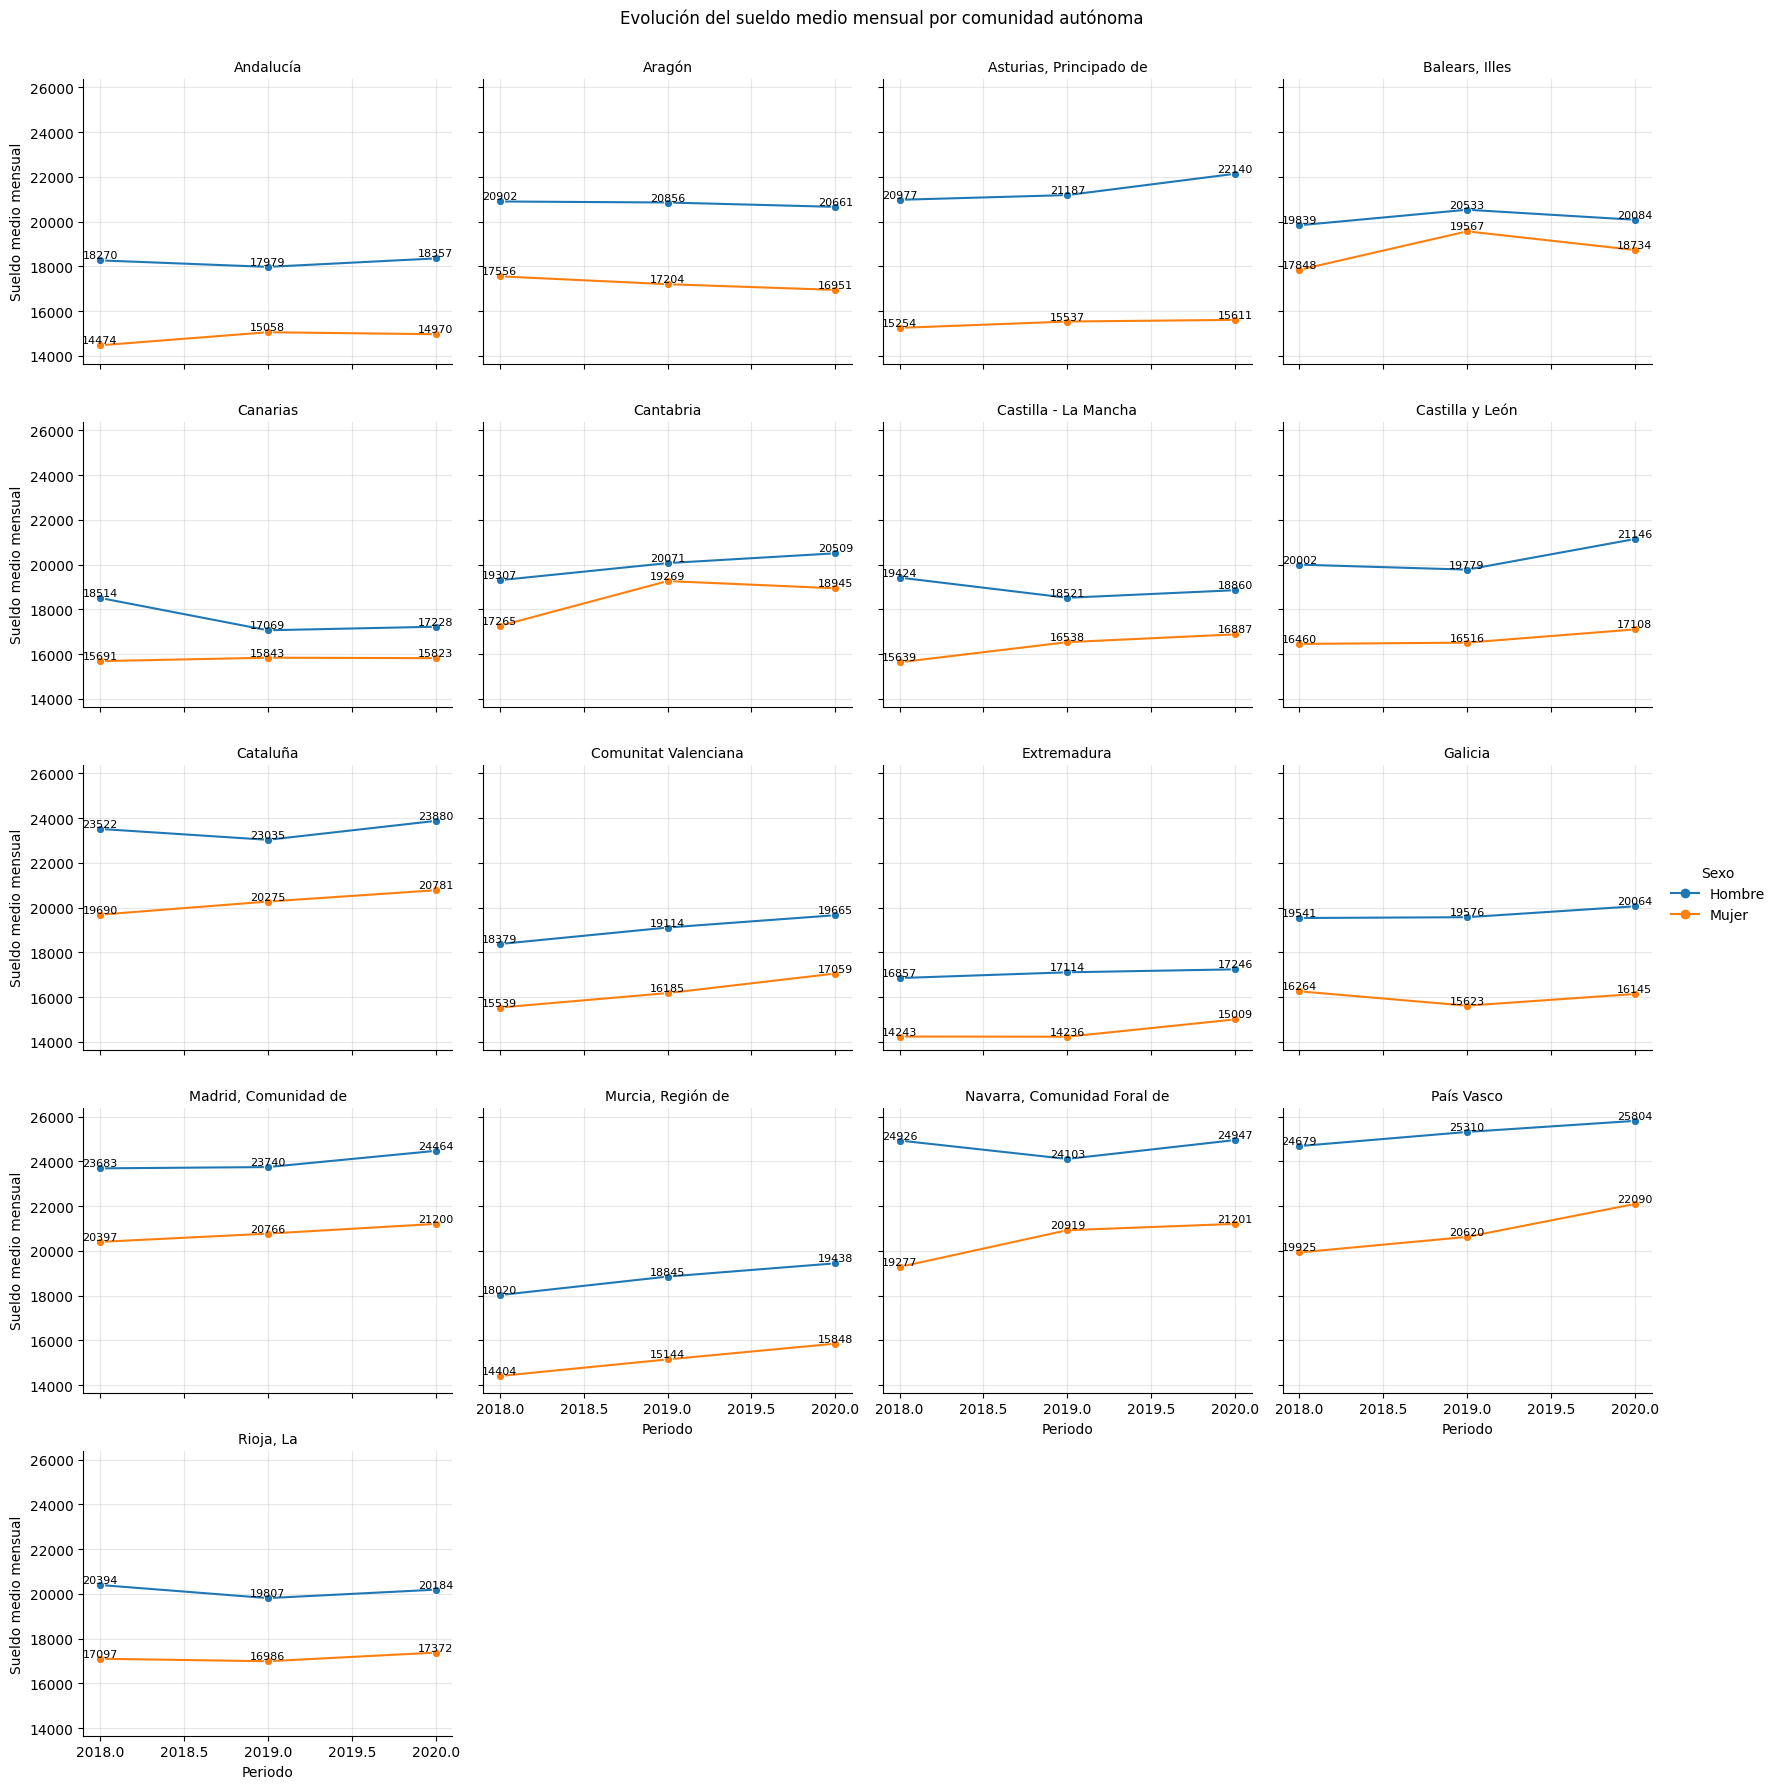

In [23]:
df_plot = df2.copy()
df_plot["Periodo"] = pd.to_numeric(df_plot["Periodo"], errors="coerce")
df_plot = df_plot[df_plot["Sexo"].isin(["Hombre", "Mujer"])].copy()
df_plot = df_plot.sort_values(["Comunidades y Ciudades Autónomas", "Sexo", "Periodo"])

g = sns.relplot(
    data=df_plot,
    x="Periodo",
    y="Total",
    hue="Sexo",
    kind="line",
    col="Comunidades y Ciudades Autónomas",
    col_wrap=4,
    marker="o",
    height=3.5,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True}
)

g.set_axis_labels("Periodo", "Sueldo medio mensual")
g.set_titles("{col_name}")
g.fig.suptitle("Evolución del sueldo medio mensual por comunidad autónoma", y=1.02)

for ax in g.axes.flat:
    titulo = ax.get_title().replace("Comunidades y Ciudades Autónomas = ", "")
    datos_ax = df_plot[df_plot["Comunidades y Ciudades Autónomas"] == titulo]

    for _, row in datos_ax.iterrows():
        ax.text(
            row["Periodo"],
            row["Total"],
            f'{row["Total"]:.0f}',
            fontsize=8,
            ha="center",
            va="bottom"
        )

    ax.grid(True, alpha=0.3)

plt.show()

periodos = sorted(df1_nogenero["periodo"].unique())

for periodo in periodos:
    datos = df1_nogenero[df1_nogenero["periodo"] == periodo].copy()
    datos = datos.sort_values("No emancipado%", ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=datos,
        x="No emancipado%",
        y="Comunidades y Ciudades Autónomas",
        order=datos["Comunidades y Ciudades Autónomas"]
    )

    plt.title(f"Proporción de no emancipados por comunidad autónoma - {periodo}")
    plt.xlabel("No emancipado (%)")
    plt.ylabel("")

    for i, valor in enumerate(datos["No emancipado%"]):
        plt.text(valor + 0.2, i, f"{valor:.1f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

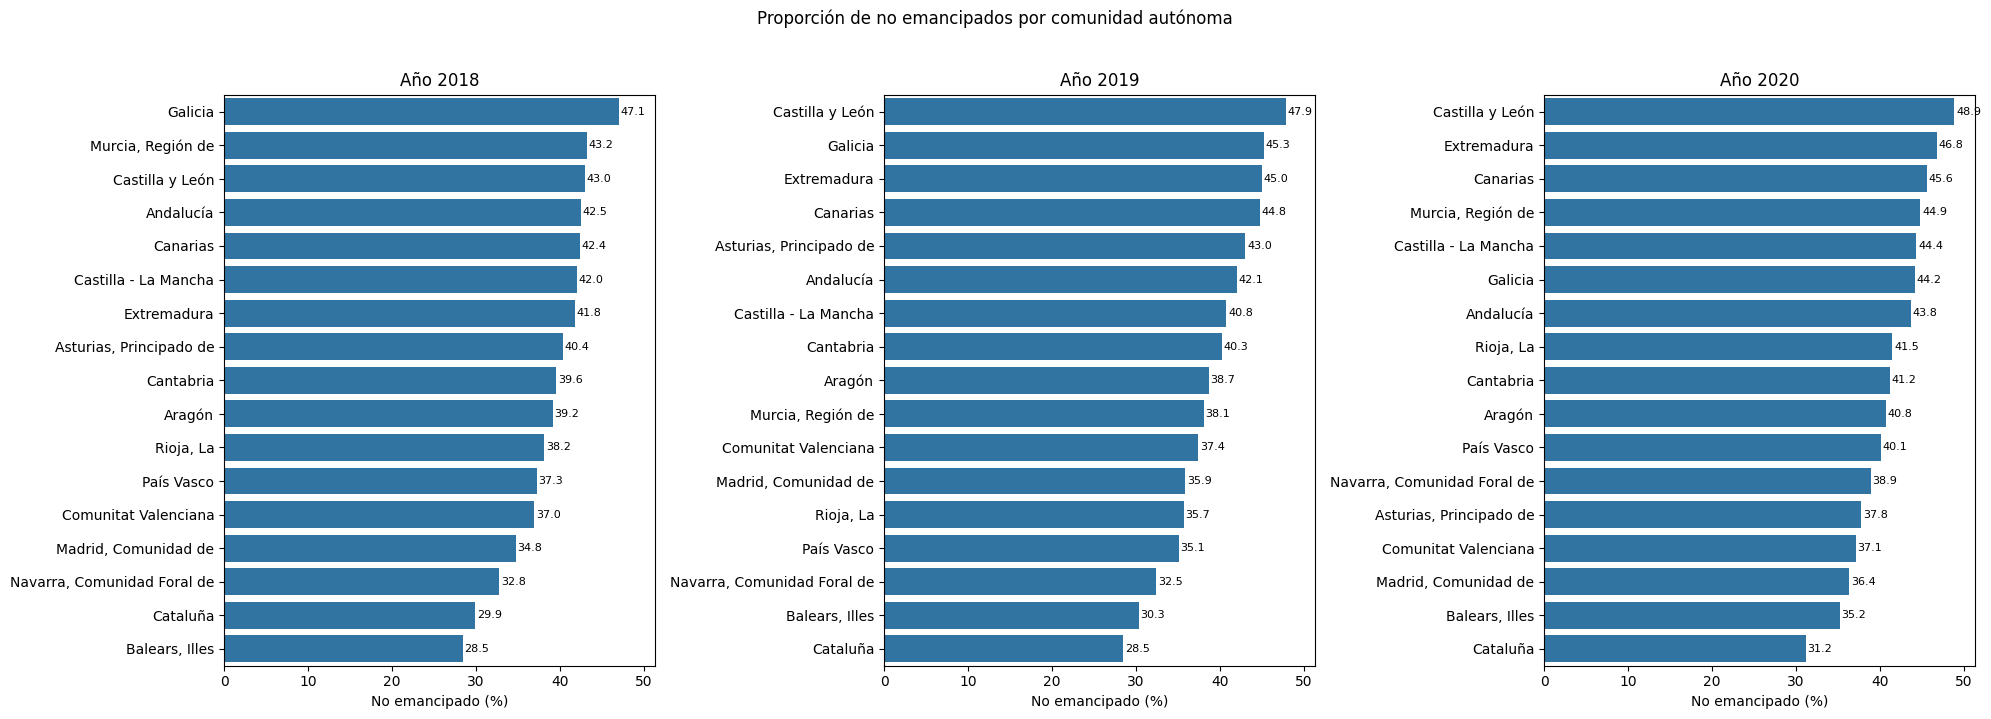

In [24]:
periodos = sorted(df1_nogenero["periodo"].unique())

fig, axes = plt.subplots(1, len(periodos), figsize=(20, 7), sharex=True)

if len(periodos) == 1:
    axes = [axes]

for ax, periodo in zip(axes, periodos):
    datos = df1_nogenero[df1_nogenero["periodo"] == periodo].copy()
    datos = datos.sort_values("No emancipado%", ascending=False)

    sns.barplot(
        data=datos,
        x="No emancipado%",
        y="Comunidades y Ciudades Autónomas",
        ax=ax,
        order=datos["Comunidades y Ciudades Autónomas"]
    )

    ax.set_title(f"Año {periodo}")
    ax.set_xlabel("No emancipado (%)")
    ax.set_ylabel("")

    for i, valor in enumerate(datos["No emancipado%"]):
        ax.text(valor + 0.2, i, f"{valor:.1f}", va="center", fontsize=8)

plt.suptitle("Proporción de no emancipados por comunidad autónoma", y=1.02)
plt.tight_layout()
plt.show()

periodos = sorted(df2_nogenero["Periodo"].unique())

for periodo in periodos:
    datos = df2_nogenero[df2_nogenero["Periodo"] == periodo].copy()
    datos = datos.sort_values("Total", ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=datos,
        x="Total",
        y="Comunidades y Ciudades Autónomas",
        order=datos["Comunidades y Ciudades Autónomas"]
    )

    plt.title(f"Salario medio anual por comunidad autónoma - {periodo}")
    plt.xlabel("Salario medio anual")
    plt.ylabel("")

    for i, valor in enumerate(datos["Total"]):
        plt.text(valor + 100, i, f"{valor:.0f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

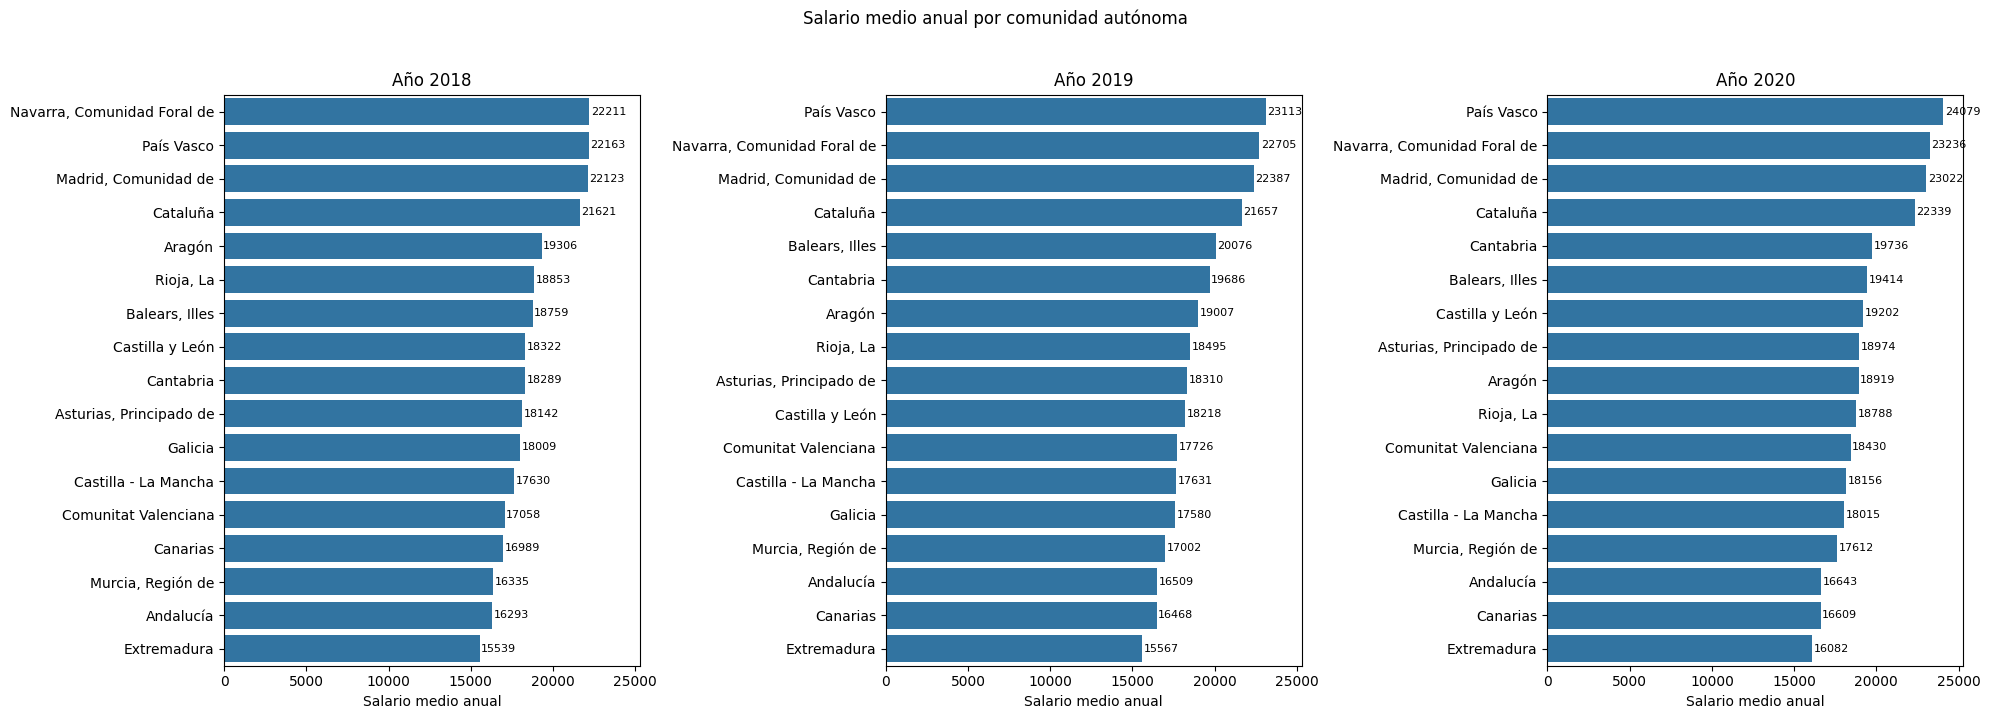

In [25]:
periodos = sorted(df2_nogenero["Periodo"].unique())

fig, axes = plt.subplots(1, len(periodos), figsize=(20, 7), sharex=True)

if len(periodos) == 1:
    axes = [axes]

for ax, periodo in zip(axes, periodos):
    datos = df2_nogenero[df2_nogenero["Periodo"] == periodo].copy()
    datos = datos.sort_values("Total", ascending=False)

    sns.barplot(
        data=datos,
        x="Total",
        y="Comunidades y Ciudades Autónomas",
        ax=ax,
        order=datos["Comunidades y Ciudades Autónomas"]
    )

    ax.set_title(f"Año {periodo}")
    ax.set_xlabel("Salario medio anual")
    ax.set_ylabel("")

    for i, valor in enumerate(datos["Total"]):
        ax.text(valor + 100, i, f"{valor:.0f}", va="center", fontsize=8)

plt.suptitle("Salario medio anual por comunidad autónoma", y=1.02)
plt.tight_layout()
plt.show()

Análisis Multivariante

df_scatter = df1_nogenero.merge(
    df2_nogenero,
    left_on=["Comunidades y Ciudades Autónomas", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Periodo"],
    how="inner"
)

periodos = sorted(df_scatter["periodo"].unique())

for periodo in periodos:
    datos = df_scatter[df_scatter["periodo"] == periodo].copy()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=datos,
        x="No emancipado%",
        y="Total",
        s=80
    )

    for _, row in datos.iterrows():
        plt.text(
            row["No emancipado%"] + 0.1,
            row["Total"],
            row["Comunidades y Ciudades Autónomas"],
            fontsize=8
        )

    plt.title(f"No emancipados (%) y salario medio anual - {periodo}")
    plt.xlabel("No emancipado (%)")
    plt.ylabel("Salario medio anual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

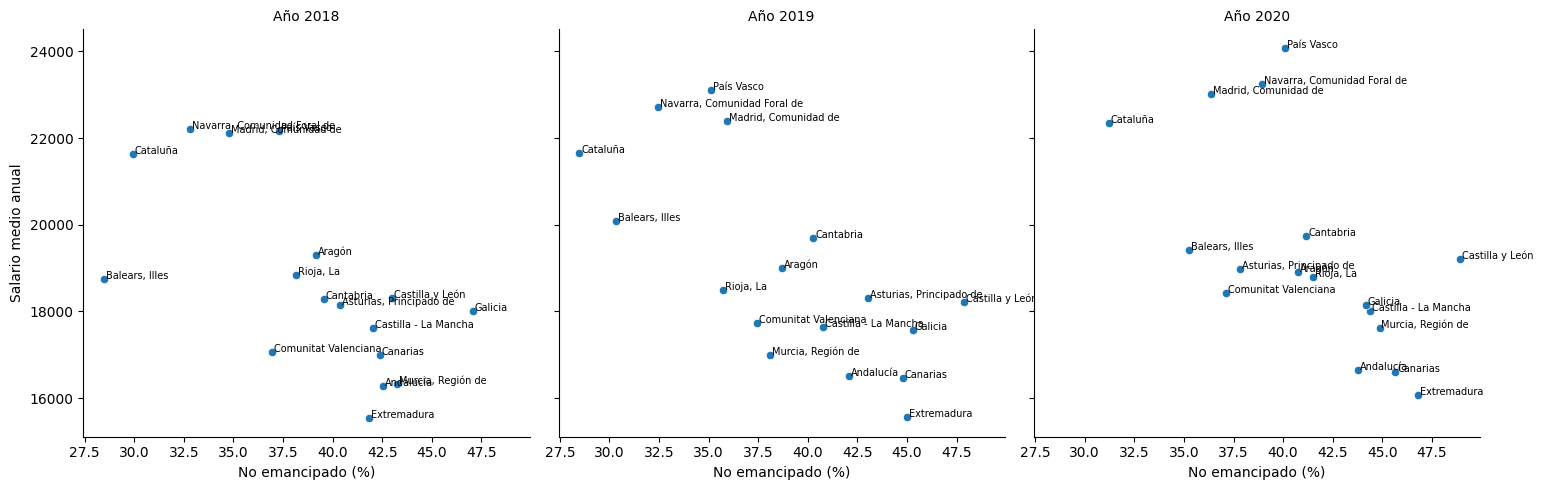

In [26]:
df_scatter = df1_nogenero.merge(
    df2_nogenero,
    left_on=["Comunidades y Ciudades Autónomas", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Periodo"],
    how="inner"
)

g = sns.relplot(
    data=df_scatter,
    x="No emancipado%",
    y="Total",
    col="periodo",
    kind="scatter",
    height=5,
    aspect=1
)

for ax, periodo in zip(g.axes.flat, sorted(df_scatter["periodo"].unique())):
    datos = df_scatter[df_scatter["periodo"] == periodo]
    for _, row in datos.iterrows():
        ax.text(
            row["No emancipado%"] + 0.1,
            row["Total"],
            row["Comunidades y Ciudades Autónomas"],
            fontsize=7
        )

g.set_axis_labels("No emancipado (%)", "Salario medio anual")
g.set_titles("Año {col_name}")
plt.show()

In [27]:
tabla_cruzada = df1_nogenero.merge(
    df2_nogenero,
    left_on=["Comunidades y Ciudades Autónomas", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Periodo"],
    how="inner"
)[[
    "Comunidades y Ciudades Autónomas",
    "periodo",
    "No emancipado%",
    "Total"
]]

tabla_cruzada = tabla_cruzada.rename(columns={"Total": "Salario medio anual"})

tabla_no_emancipado = tabla_cruzada.pivot(
    index="Comunidades y Ciudades Autónomas",
    columns="periodo",
    values="No emancipado%"
)

tabla_no_emancipado.columns = [f"no_emancipado_{col}" for col in tabla_no_emancipado.columns]

tabla_salario = tabla_cruzada.pivot(
    index="Comunidades y Ciudades Autónomas",
    columns="periodo",
    values="Salario medio anual"
)

tabla_salario.columns = [f"salario_{col}" for col in tabla_salario.columns]

tabla_final = tabla_no_emancipado.merge(
    tabla_salario,
    left_index=True,
    right_index=True
).reset_index()

tabla_final

,Comunidades y Ciudades Autónomas,no_emancipado_2018,no_emancipado_2019,no_emancipado_2020,salario_2018,salario_2019,salario_2020
0,Andalucía,42.531,42.066,43.754,16293.48,16509.01,16643.35
1,Aragón,39.175,38.679,40.77,19306.31,19006.76,18919.42
2,"Asturias, Principado de",40.356,43.045,37.826,18141.88,18309.70,18973.91
3,"Balears, Illes",28.455,30.324,35.243,18759.36,20075.72,19413.73
4,Canarias,42.376,44.782,45.648,16988.89,16467.90,16608.61
5,Cantabria,39.555,40.283,41.166,18289.24,19686.42,19736.18
6,Castilla - La Mancha,42.031,40.778,44.377,17629.80,17631.22,18014.77
7,Castilla y León,42.978,47.879,48.9,18322.20,18217.73,19201.93
8,Cataluña,29.937,28.484,31.207,21621.47,21656.58,22338.55
9,Comunitat Valenciana,36.95,37.422,37.137,17057.95,17726.16,18430.18


In [28]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo]

    stat_no, p_no = shapiro(datos["No emancipado%"])
    stat_sal, p_sal = shapiro(datos["Salario medio anual"])

    print(f"Año {periodo}")
    print(f"No emancipado% -> estadístico={stat_no:.4f}, p-valor={p_no:.4f}")
    print(f"Salario medio anual -> estadístico={stat_sal:.4f}, p-valor={p_sal:.4f}")


Año 2018
No emancipado% -> estadístico=0.9424, p-valor=0.3471
Salario medio anual -> estadístico=0.8982, p-valor=0.0634
Año 2019
No emancipado% -> estadístico=0.9749, p-valor=0.8966
Salario medio anual -> estadístico=0.9247, p-valor=0.1776
Año 2020
No emancipado% -> estadístico=0.9820, p-valor=0.9732
Salario medio anual -> estadístico=0.9003, p-valor=0.0687


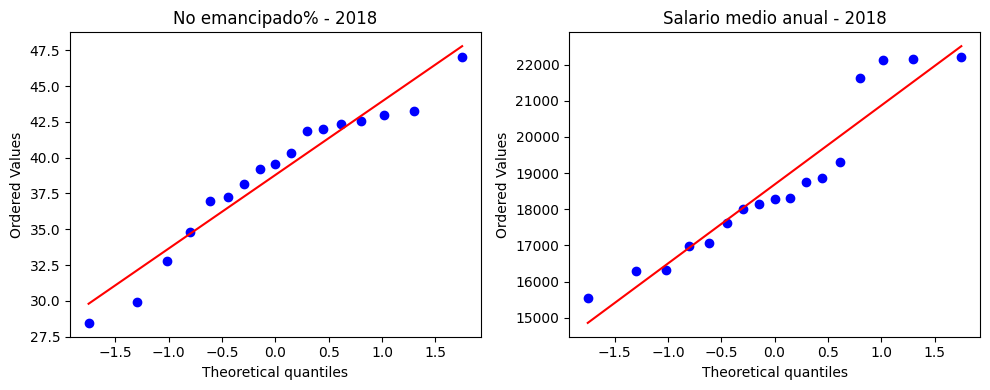

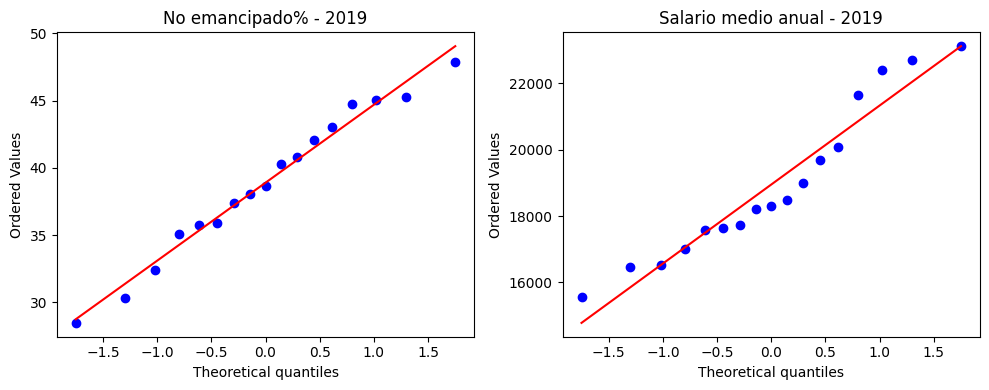

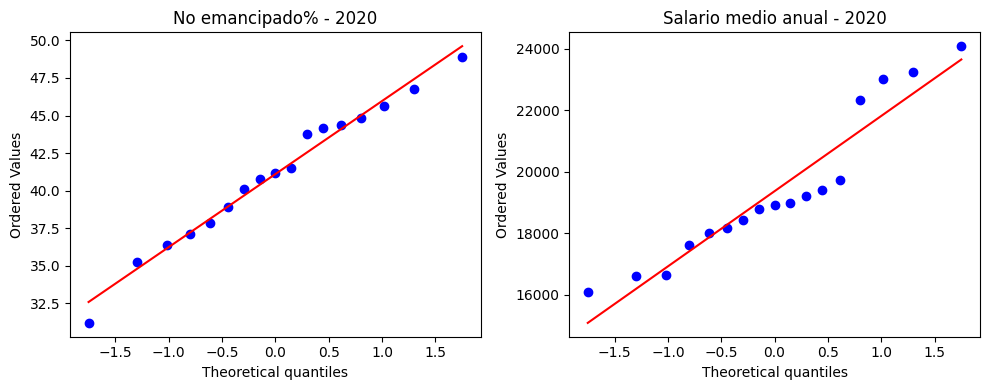

In [29]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    stats.probplot(datos["No emancipado%"], dist="norm", plot=axes[0])
    axes[0].set_title(f"No emancipado% - {periodo}")

    stats.probplot(datos["Salario medio anual"], dist="norm", plot=axes[1])
    axes[1].set_title(f"Salario medio anual - {periodo}")

    plt.tight_layout()
    plt.show()

In [30]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo]

    r, p = pearsonr(
        datos["No emancipado%"],
        datos["Salario medio anual"]
    )

    print(f"Año {periodo}")
    print(f"r = {r:.4f}")
    print(f"p-valor = {p:.4f}")

Año 2018
r = -0.6428
p-valor = 0.0054
Año 2019
r = -0.7130
p-valor = 0.0013
Año 2020
r = -0.6131
p-valor = 0.0089


In [31]:
for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo].copy()

    X = datos["Salario medio anual"]
    y = datos["No emancipado%"]
    
    X = sm.add_constant(X)
    
    modelo = sm.OLS(y, X).fit()

    print(f"\nAño {periodo}")
    print(modelo.summary())


Año 2018
                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     10.56
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00538
Time:                        10:53:27   Log-Likelihood:                -46.408
No. Observations:                  17   AIC:                             96.82
Df Residuals:                      15   BIC:                             98.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  6

for periodo in sorted(tabla_cruzada["periodo"].unique()):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo].copy()

    r, p = pearsonr(datos["Salario medio anual"], datos["No emancipado%"])

    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=datos,
        x="Salario medio anual",
        y="No emancipado%",
        scatter_kws={"s": 70},
        line_kws={"color": "red"}
    )

    for _, row in datos.iterrows():
        plt.text(
            row["Salario medio anual"] + 50,
            row["No emancipado%"],
            row["Comunidades y Ciudades Autónomas"],
            fontsize=8
        )

    plt.text(
        0.05, 0.95,
        f"r = {r:.3f}\np = {p:.3f}",
        transform=plt.gca().transAxes,
        ha="left",
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.title(f"Salario y no emancipados - {periodo}")
    plt.xlabel("Salario medio anual")
    plt.ylabel("No emancipado (%)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

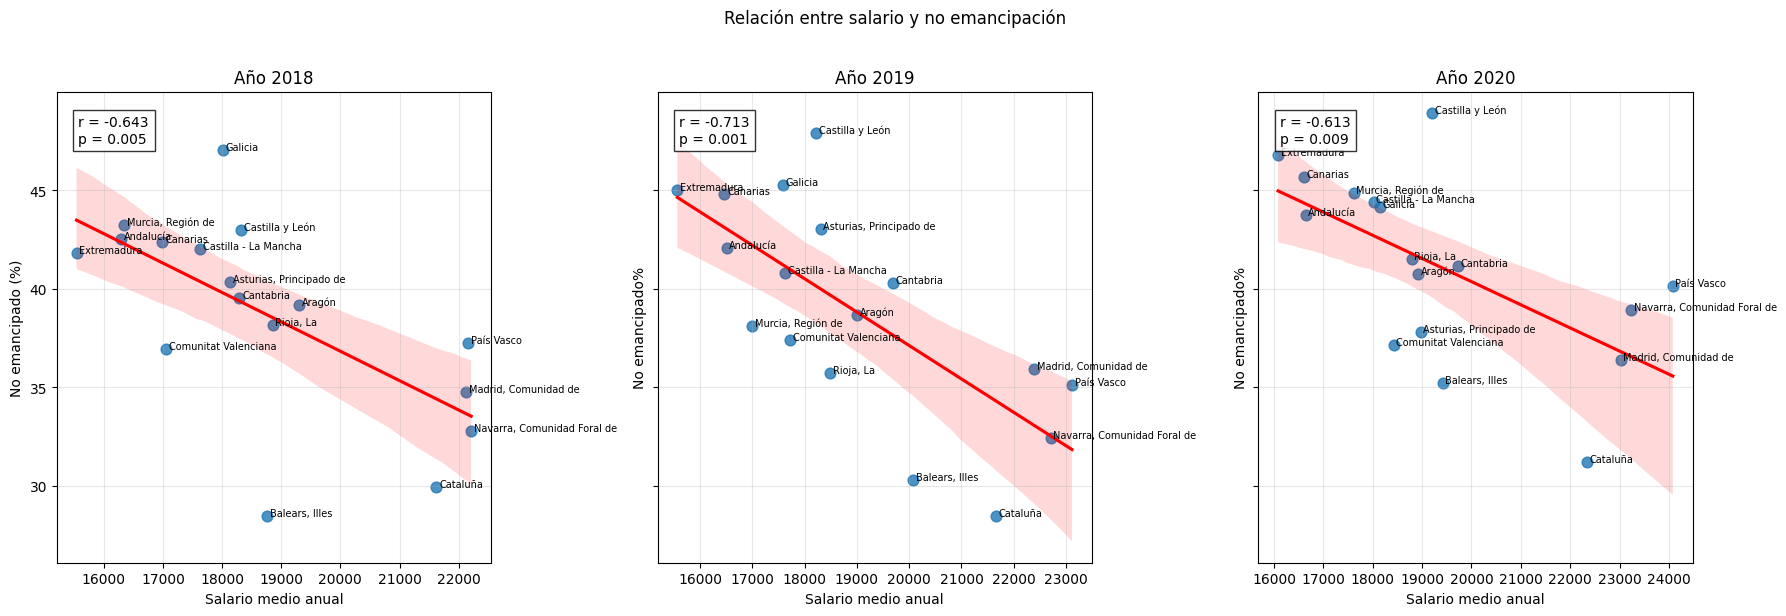

In [32]:
periodos = sorted(tabla_cruzada["periodo"].unique())

fig, axes = plt.subplots(1, len(periodos), figsize=(18, 6), sharey=True)

if len(periodos) == 1:
    axes = [axes]

for ax, periodo in zip(axes, periodos):
    datos = tabla_cruzada[tabla_cruzada["periodo"] == periodo].copy()

    r, p = pearsonr(datos["Salario medio anual"], datos["No emancipado%"])

    sns.regplot(
        data=datos,
        x="Salario medio anual",
        y="No emancipado%",
        ax=ax,
        scatter_kws={"s": 60},
        line_kws={"color": "red"}
    )

    for _, row in datos.iterrows():
        ax.text(
            row["Salario medio anual"] + 50,
            row["No emancipado%"],
            row["Comunidades y Ciudades Autónomas"],
            fontsize=7
        )

    ax.text(
        0.05, 0.95,
        f"r = {r:.3f}\np = {p:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(f"Año {periodo}")
    ax.set_xlabel("Salario medio anual")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("No emancipado (%)")
plt.suptitle("Relación entre salario y no emancipación", y=1.02)
plt.tight_layout()
plt.show()

In [33]:
tabla_cruzada_sexo = df1.merge(
    df2,
    left_on=["Comunidades y Ciudades Autónomas", "Sexo", "periodo"],
    right_on=["Comunidades y Ciudades Autónomas", "Sexo", "Periodo"],
    how="inner"
)[[
    "Comunidades y Ciudades Autónomas",
    "Sexo",
    "periodo",
    "No emancipado%",
    "Total"
]]

tabla_cruzada_sexo = tabla_cruzada_sexo.rename(columns={
    "Total": "Sueldo medio anual"
})

tabla_cruzada_sexo = tabla_cruzada_sexo.sort_values(
    ["periodo", "Comunidades y Ciudades Autónomas", "Sexo"]
)

tabla_final_sexo = tabla_cruzada_sexo.pivot(
    index="Comunidades y Ciudades Autónomas",
    columns=["periodo", "Sexo"],
    values=["No emancipado%", "Sueldo medio anual"]
)

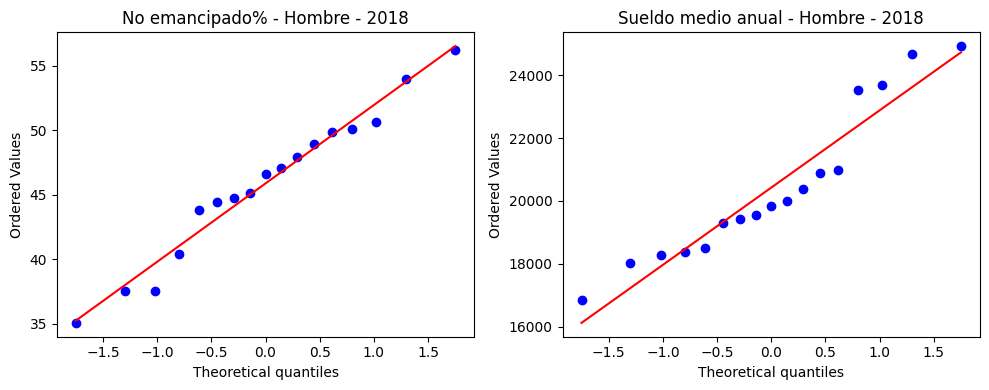

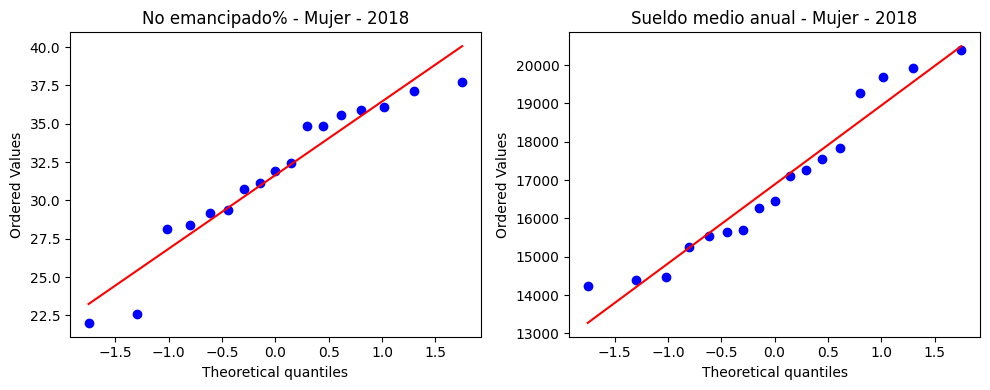

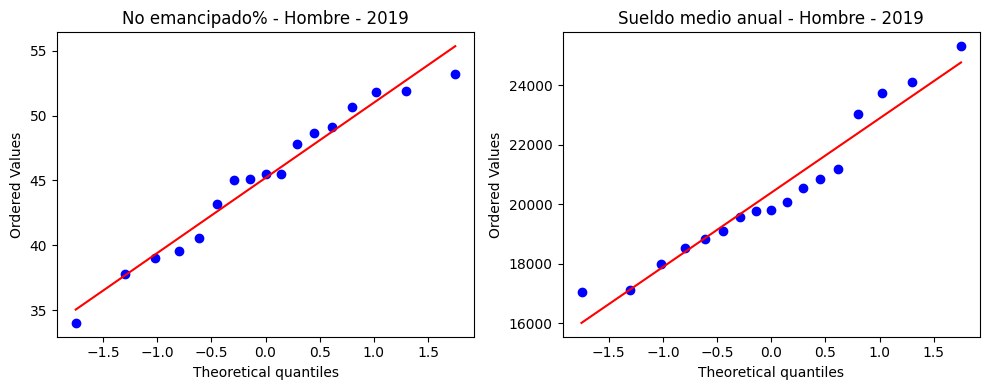

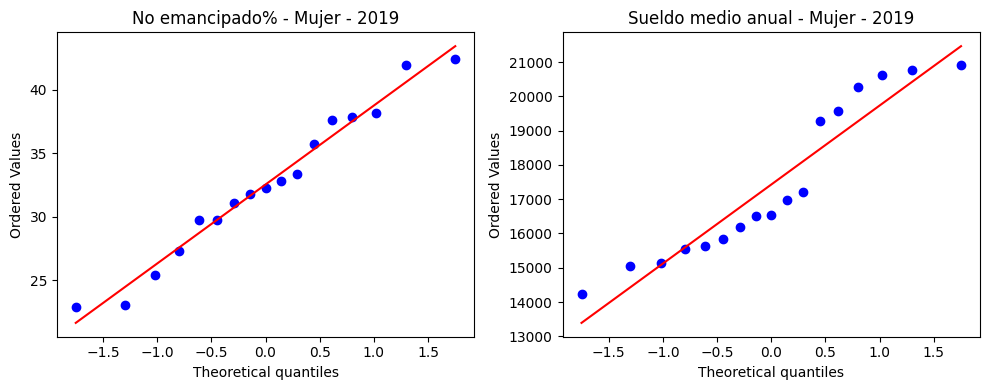

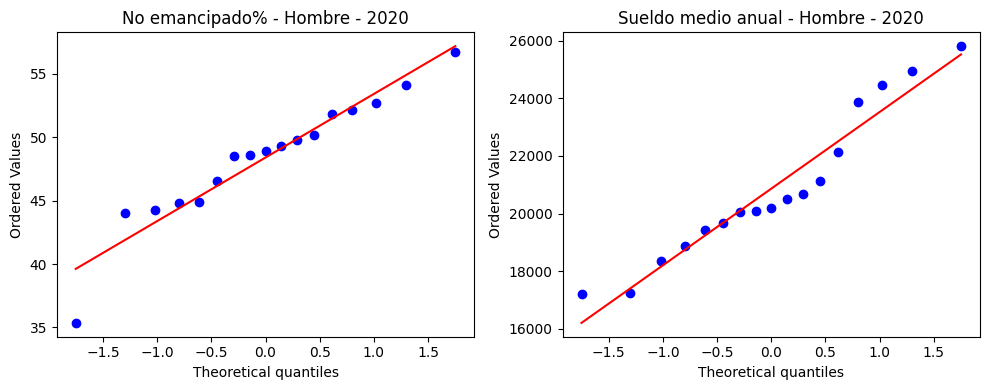

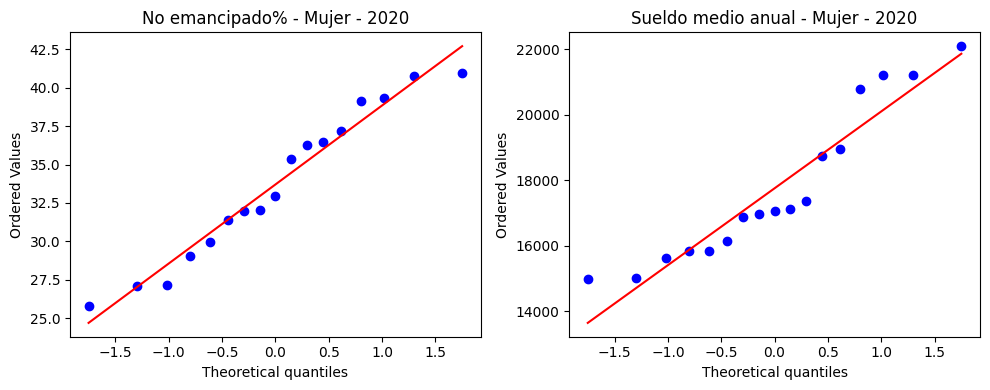

In [34]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        stats.probplot(datos["No emancipado%"], dist="norm", plot=axes[0])
        axes[0].set_title(f"No emancipado% - {sexo} - {periodo}")

        stats.probplot(datos["Sueldo medio anual"], dist="norm", plot=axes[1])
        axes[1].set_title(f"Sueldo medio anual - {sexo} - {periodo}")

        plt.tight_layout()
        plt.show()

In [35]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        stat_no, p_no = shapiro(datos["No emancipado%"])
        stat_sal, p_sal = shapiro(datos["Sueldo medio anual"])

        print(f"Año {periodo} - {sexo}")
        print(f"No emancipado% -> estadístico={stat_no:.4f}, p-valor={p_no:.4f}")
        print(f"Sueldo medio anual -> estadístico={stat_sal:.4f}, p-valor={p_sal:.4f}")

Año 2018 - Hombre
No emancipado% -> estadístico=0.9709, p-valor=0.8332
Sueldo medio anual -> estadístico=0.9085, p-valor=0.0942
Año 2018 - Mujer
No emancipado% -> estadístico=0.9231, p-valor=0.1667
Sueldo medio anual -> estadístico=0.9300, p-valor=0.2173
Año 2019 - Hombre
No emancipado% -> estadístico=0.9586, p-valor=0.6059
Sueldo medio anual -> estadístico=0.9378, p-valor=0.2930
Año 2019 - Mujer
No emancipado% -> estadístico=0.9645, p-valor=0.7167
Sueldo medio anual -> estadístico=0.8855, p-valor=0.0391
Año 2020 - Hombre
No emancipado% -> estadístico=0.9410, p-valor=0.3302
Sueldo medio anual -> estadístico=0.9295, p-valor=0.2139
Año 2020 - Mujer
No emancipado% -> estadístico=0.9471, p-valor=0.4116
Sueldo medio anual -> estadístico=0.8901, p-valor=0.0465


In [36]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ]

        r, p = pearsonr(
            datos["No emancipado%"],
            datos["Sueldo medio anual"]
        )

        print(f"Año {periodo} - {sexo}")
        print(f"r = {r:.4f}")
        print(f"p-valor = {p:.4f}")

Año 2018 - Hombre
r = -0.5903
p-valor = 0.0126
Año 2018 - Mujer
r = -0.6526
p-valor = 0.0045
Año 2019 - Hombre
r = -0.6170
p-valor = 0.0083
Año 2019 - Mujer
r = -0.7607
p-valor = 0.0004
Año 2020 - Hombre
r = -0.5226
p-valor = 0.0314
Año 2020 - Mujer
r = -0.5526
p-valor = 0.0214


In [37]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ].copy()

        X = datos["Sueldo medio anual"]
        y = datos["No emancipado%"]

        X = sm.add_constant(X)

        modelo = sm.OLS(y, X).fit()

        print(f"\nAño {periodo} - {sexo}")
        print(modelo.summary())


Año 2018 - Hombre
                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     8.020
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0126
Time:                        10:53:29   Log-Likelihood:                -49.864
No. Observations:                  17   AIC:                             103.7
Df Residuals:                      15   BIC:                             105.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const            

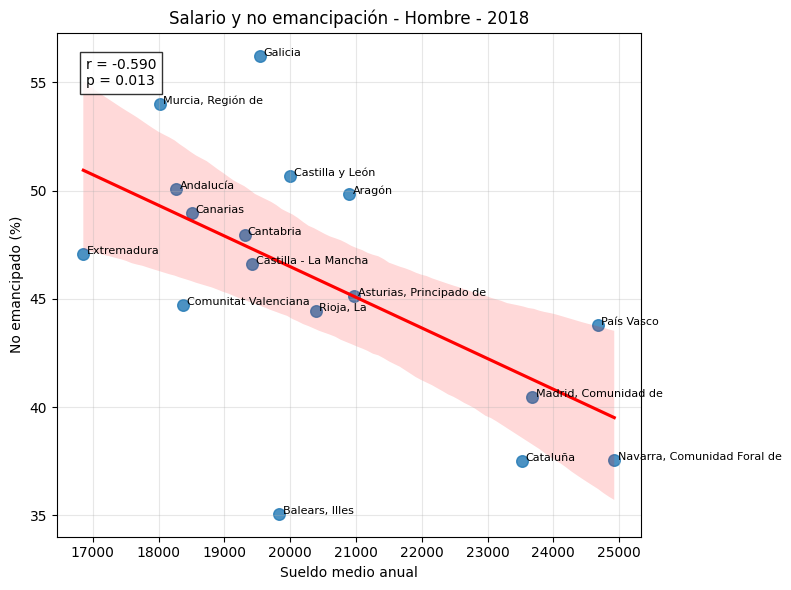

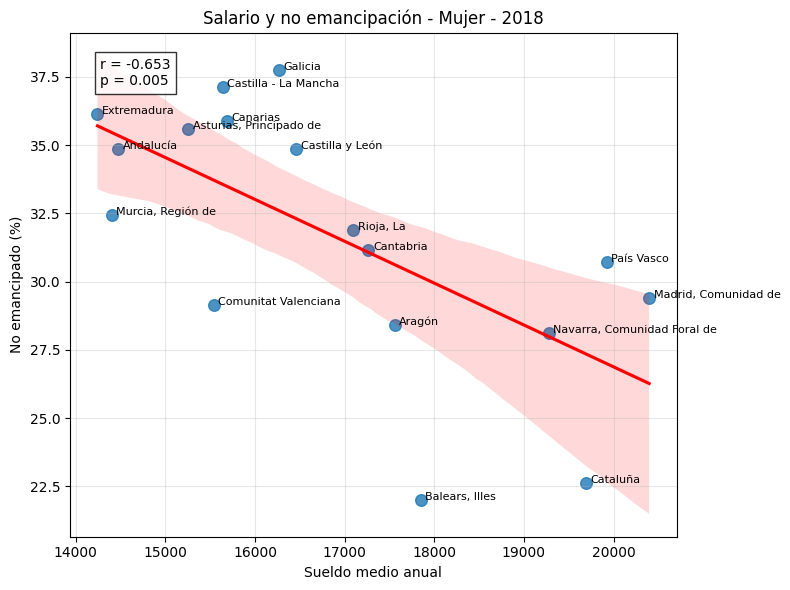

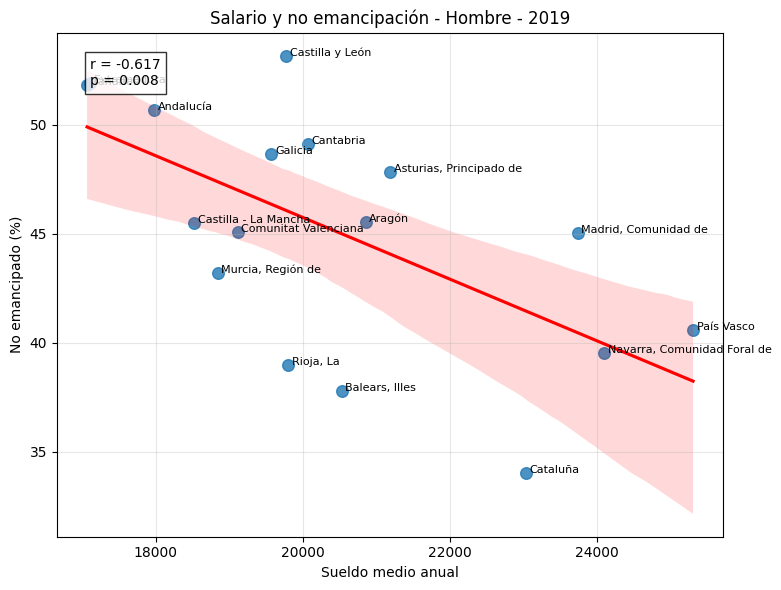

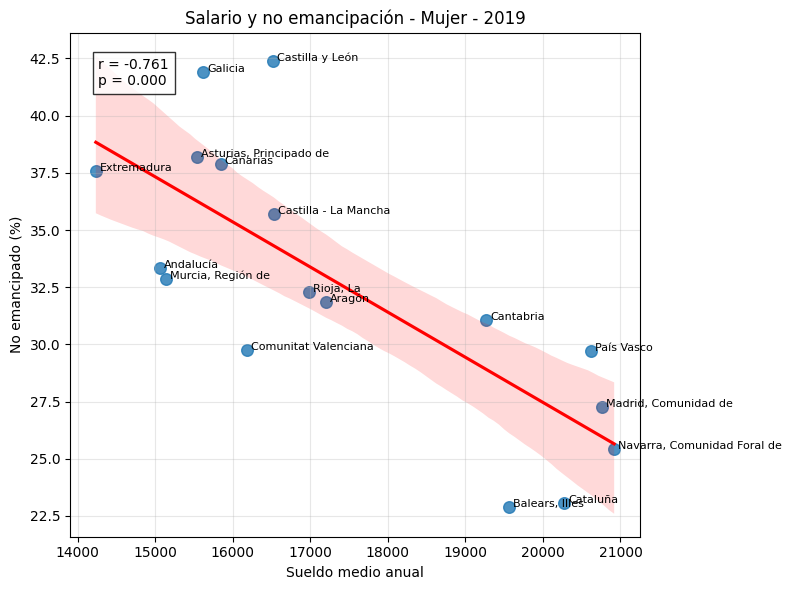

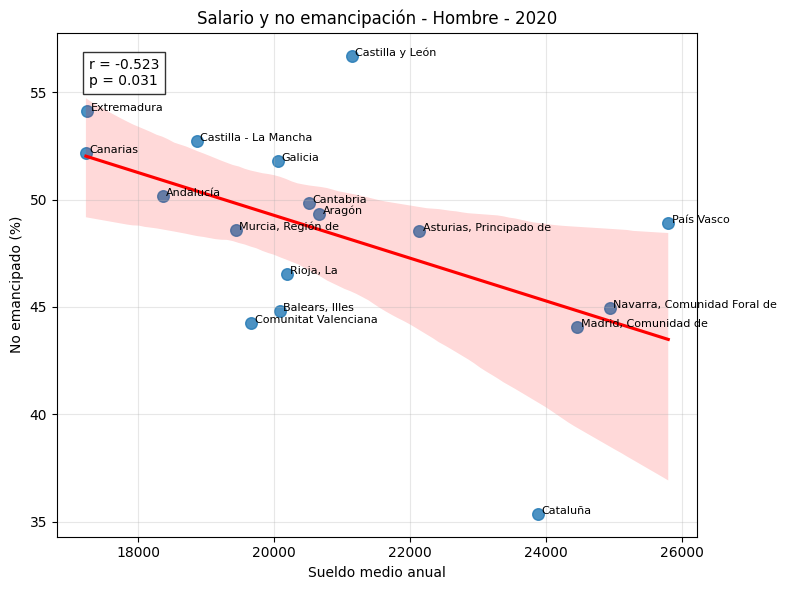

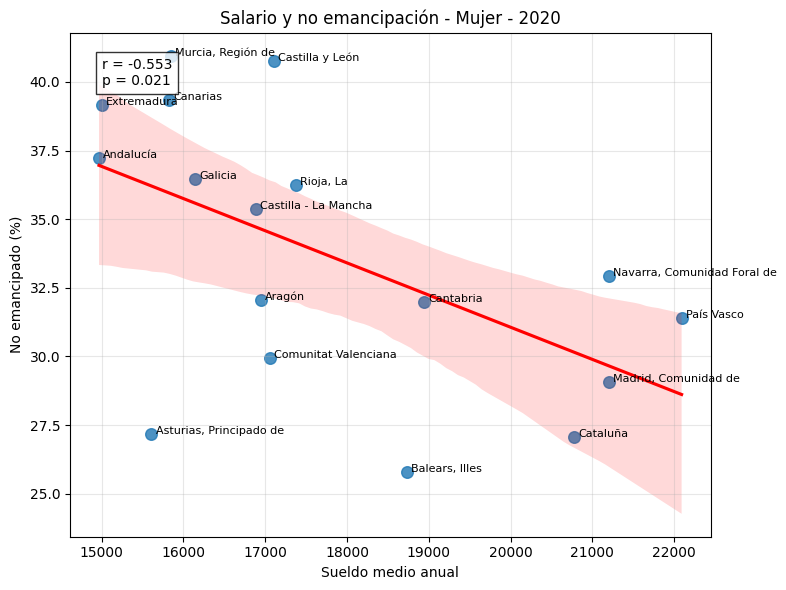

In [38]:
for periodo in sorted(tabla_cruzada_sexo["periodo"].unique()):
    for sexo in sorted(tabla_cruzada_sexo["Sexo"].unique()):
        datos = tabla_cruzada_sexo[
            (tabla_cruzada_sexo["periodo"] == periodo) &
            (tabla_cruzada_sexo["Sexo"] == sexo)
        ].copy()

        r, p = pearsonr(datos["Sueldo medio anual"], datos["No emancipado%"])

        plt.figure(figsize=(8, 6))
        sns.regplot(
            data=datos,
            x="Sueldo medio anual",
            y="No emancipado%",
            scatter_kws={"s": 70},
            line_kws={"color": "red"}
        )

        for _, row in datos.iterrows():
            plt.text(
                row["Sueldo medio anual"] + 50,
                row["No emancipado%"],
                row["Comunidades y Ciudades Autónomas"],
                fontsize=8
            )

        plt.text(
            0.05, 0.95,
            f"r = {r:.3f}\np = {p:.3f}",
            transform=plt.gca().transAxes,
            ha="left",
            va="top",
            bbox=dict(facecolor="white", alpha=0.8)
        )

        plt.title(f"Salario y no emancipación - {sexo} - {periodo}")
        plt.xlabel("Sueldo medio anual")
        plt.ylabel("No emancipado (%)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [39]:
datos_modelo = tabla_cruzada_sexo.copy()

# Dummy de genero: 0 = Hombre, 1 = Mujer
datos_modelo["genero_dummy"] = datos_modelo["Sexo"].map({
    "Hombre": 0,
    "Mujer": 1
})

X = datos_modelo[["Sueldo medio anual", "genero_dummy"]]
y = datos_modelo["No emancipado%"]

X = sm.add_constant(X)

modelo_conjunto = sm.OLS(y, X).fit()

print(modelo_conjunto.summary())

                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     149.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.14e-30
Time:                        10:53:30   Log-Likelihood:                -294.59
No. Observations:                 102   AIC:                             595.2
Df Residuals:                      99   BIC:                             603.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 73.5183      3

In [40]:
datos_modelo["interaccion"] = (
    datos_modelo["Sueldo medio anual"] * datos_modelo["genero_dummy"]
)

X = datos_modelo[["Sueldo medio anual", "genero_dummy", "interaccion"]]
X = sm.add_constant(X)

modelo_interaccion = sm.OLS(y, X).fit()
print(modelo_interaccion.summary())

                            OLS Regression Results                            
Dep. Variable:         No emancipado%   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     99.44
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.28e-29
Time:                        10:53:30   Log-Likelihood:                -294.37
No. Observations:                 102   AIC:                             596.7
Df Residuals:                      98   BIC:                             607.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 71.2183      5